# N6 — t-SNE and UMAP: Nonlinear Dimensionality Reduction

This notebook provides a comprehensive, hands-on introduction to **t-SNE** and **UMAP**, two of the most powerful nonlinear dimensionality reduction techniques in modern data science.
 You will learn:

1. **Motivation** — When and why PCA falls short on nonlinear data
2. **t-SNE** — Algorithm intuition, math foundations, and hyperparameters
3. **UMAP** — Algorithm intuition, math foundations, and hyperparameters
4. **Head-to-head Comparison** — Datasets where t-SNE/UMAP outperform PCA

---

**Author:** Alejandro Ucan-Puc  
**Last Updated:** March 2026

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why PCA fails to capture nonlinear structure and when nonlinear methods are necessary.
2. Describe the key idea behind t-SNE: converting distances into probabilities and minimizing KL divergence.
3. Describe the key idea behind UMAP: constructing a fuzzy topological graph and optimizing a cross-entropy.
4. Tune the most important hyperparameters (`perplexity` for t-SNE; `n_neighbors` and `min_dist` for UMAP).
5. Choose the right method for a given task based on dataset properties and analysis goals.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import (make_swiss_roll, make_circles,
                               make_moons, load_digits, load_iris)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import umap
import time

np.random.seed(42)

In [5]:
%pip install -q "umap-learn>=0.5.7"

Note: you may need to restart the kernel to use updated packages.


In [6]:
PALETTE = {
    'bg':     '#f6f7fb',
    'grid':   '#d5d9e6',
    'ink':    '#1f2430',
    'blue':   '#2563eb',
    'orange': '#ea580c',
    'green':  '#059669',
    'rose':   '#e11d48',
    'purple': '#7c3aed'
}

rcParams['figure.figsize']      = (9, 5)
rcParams['figure.facecolor']    = PALETTE['bg']
rcParams['axes.facecolor']      = PALETTE['bg']
rcParams['axes.edgecolor']      = '#9aa4bf'
rcParams['axes.labelcolor']     = PALETTE['ink']
rcParams['axes.titleweight']    = 'bold'
rcParams['axes.titlesize']      = 13
rcParams['grid.color']          = PALETTE['grid']
rcParams['grid.linestyle']      = '--'
rcParams['grid.alpha']          = 0.85
rcParams['xtick.color']         = PALETTE['ink']
rcParams['ytick.color']         = PALETTE['ink']
rcParams['font.size']           = 11

def beautify(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True)
    if title  is not None: ax.set_title(title)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)

---

## 1. When Linear Methods Fall Short

**Principal Component Analysis (PCA)** finds the directions of maximum variance in data — it is fast, interpretable, and deterministic. However, PCA is *linear*: it can only find flat projections. Many real-world datasets live on **nonlinear manifolds** (curved surfaces embedded in high-dimensional space). A flat linear projection will *crush* together points that are far apart on the manifold and *tear apart* points that are close.

### Three canonical failure cases of PCA

| Dataset | True structure | PCA result |
|---|---|---|
| Swiss Roll | 2-D spiral sheet in 3-D | Overlapping horseshoe |
| Nested circles | Two concentric rings | Ellipses overlap completely |
| Interleaved moons | Two interlocked crescents | Inseparable blobs |

Let’s visualize these failures:

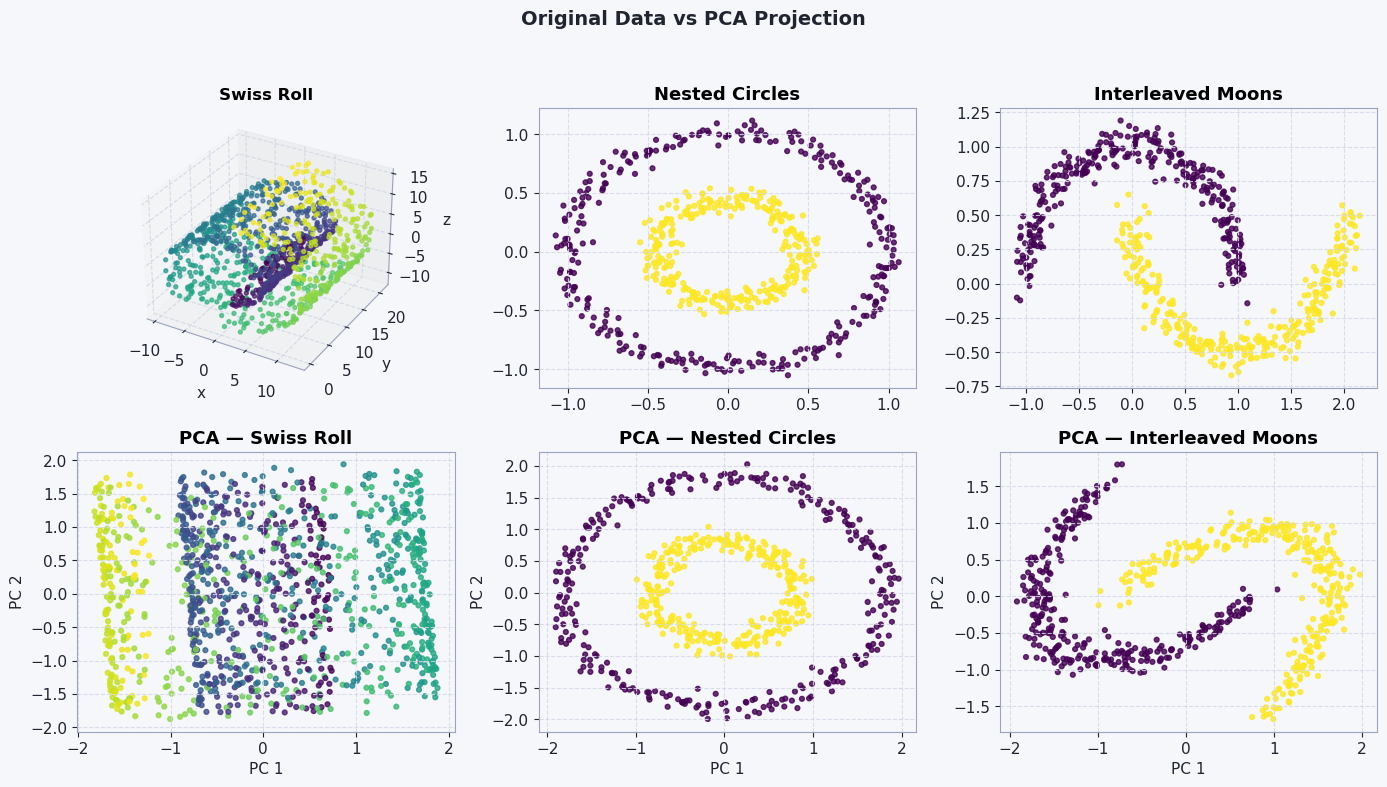

PCA cannot separate the intrinsic structure in any of these nonlinear datasets.


In [7]:
# Generate three datasets that illustrate PCA failures
X_roll, c_roll = make_swiss_roll(n_samples=1200, noise=0.12, random_state=42)
X_circ, c_circ = make_circles(n_samples=600, noise=0.05, factor=0.45, random_state=42)
X_moon, c_moon = make_moons(n_samples=600, noise=0.07, random_state=42)

scaler = StandardScaler()

fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor(PALETTE['bg'])

datasets = [
    (X_roll, c_roll, 'Swiss Roll', True),
    (X_circ, c_circ, 'Nested Circles', False),
    (X_moon, c_moon, 'Interleaved Moons', False),
]

pca_axes = []
for col, (X, c, title, is3d) in enumerate(datasets):
    # Original view
    if is3d:
        ax = fig.add_subplot(2, 3, col + 1, projection='3d')
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=c, cmap='viridis', s=8, alpha=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
        ax.set_facecolor(PALETTE['bg'])
    else:
        ax = fig.add_subplot(2, 3, col + 1)
        ax.set_facecolor(PALETTE['bg'])
        ax.scatter(X[:, 0], X[:, 1], c=c, cmap='viridis', s=12, alpha=0.8)
        beautify(ax, title=title)

    # PCA 2-D projection
    X_pca = PCA(n_components=2).fit_transform(scaler.fit_transform(X))
    ax2 = fig.add_subplot(2, 3, col + 4)
    ax2.set_facecolor(PALETTE['bg'])
    ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=c, cmap='viridis', s=12, alpha=0.8)
    beautify(ax2, title=f'PCA — {title}', xlabel='PC 1', ylabel='PC 2')

fig.suptitle('Original Data vs PCA Projection', fontsize=14,
             fontweight='bold', color=PALETTE['ink'])
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print('PCA cannot separate the intrinsic structure in any of these nonlinear datasets.')

---

## 2. t-SNE — t-distributed Stochastic Neighbor Embedding

t-SNE was introduced by **Van der Maaten & Hinton (2008)**. Its core idea: convert pairwise *distances* into pairwise *probabilities* and find a low-dimensional layout whose probability distribution matches as closely as possible.

### Step 1 — High-dimensional similarities

For each pair of points $x_i, x_j \in \mathbb{R}^D$, define a **conditional probability**:

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

where $\sigma_i$ is chosen so that the entropy of $p_{\cdot|i}$ equals $\log_2(\text{perplexity})$. Symmetrize: $p_{ij} = (p_{j|i} + p_{i|j}) / 2n$.

### Step 2 — Low-dimensional similarities (Cauchy kernel)

In the $d$-dimensional embedding $\{y_i\}$, use a **t-Student ($\nu=1$)** kernel:

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\displaystyle\sum_{k \neq l}(1 + \|y_k - y_l\|^2)^{-1}}$$

The heavy tail prevents the *crowding problem*: widely separated clusters stay separated.

### Step 3 — Minimize KL Divergence

$$\mathcal{L} = D_{\text{KL}}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Optimized via **gradient descent with momentum** and an *early exaggeration* phase that pushes clusters apart before refining local structure.

### Key Hyperparameters

| Parameter | Typical range | Effect |
|---|---|---|
| `perplexity` | 5 – 50 | Effective neighborhood size |
| `learning_rate` | 10 – 1000 (or `'auto'`) | Gradient descent step size |
| `n_iter` | ≥ 1000 | Number of optimization steps |
| `early_exaggeration` | 4 – 30 | Pushes clusters apart initially |

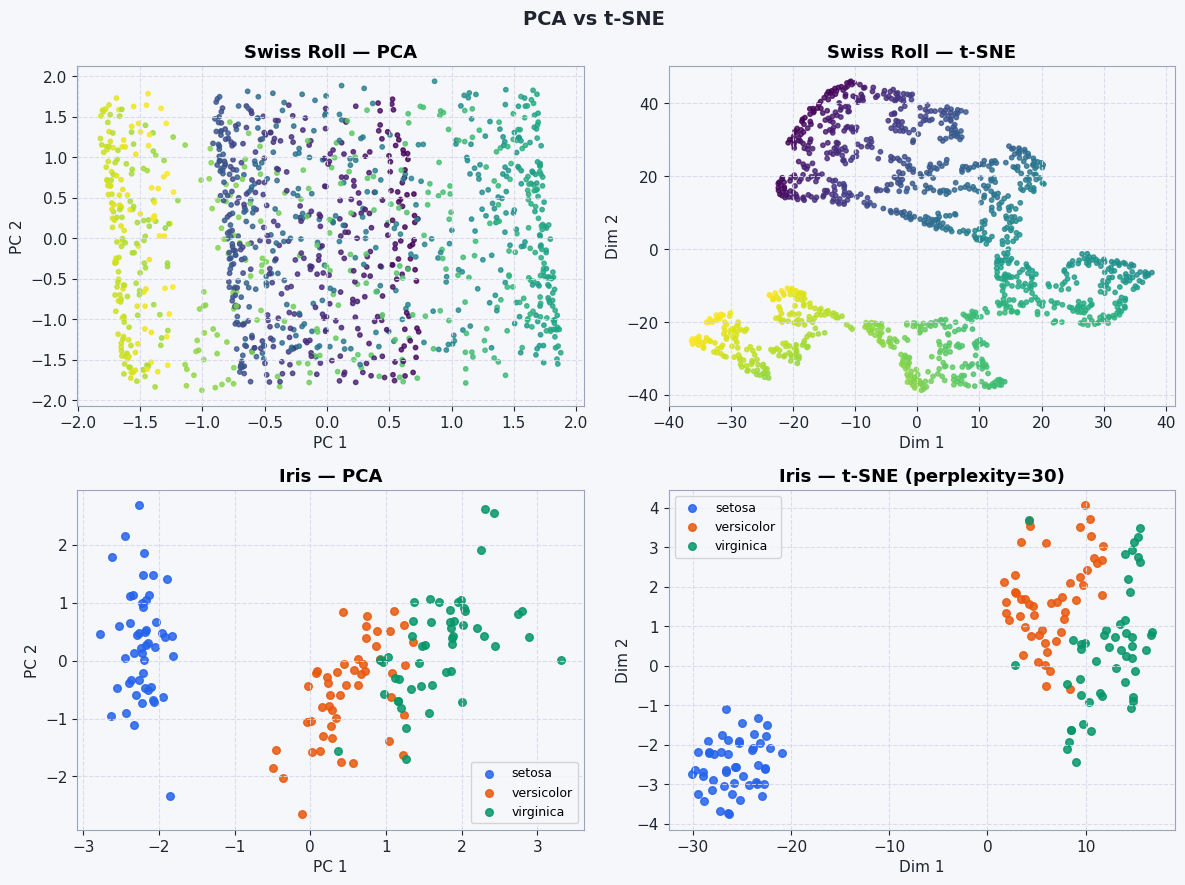

t-SNE clearly separates versicolor/virginica that PCA partially overlaps.


In [8]:
# t-SNE on Swiss Roll and Iris
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target
colors_iris = [PALETTE['blue'], PALETTE['orange'], PALETTE['green']]

X_roll_sc   = StandardScaler().fit_transform(X_roll)
X_roll_pca  = PCA(n_components=2).fit_transform(X_roll_sc)
X_roll_tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                   random_state=42).fit_transform(X_roll_sc)

X_iris_pca  = PCA(n_components=2).fit_transform(X_iris)
X_iris_tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                   random_state=42).fit_transform(X_iris)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(X_roll_pca[:, 0], X_roll_pca[:, 1],
                   c=c_roll, cmap='viridis', s=10, alpha=0.8)
beautify(axes[0, 0], title='Swiss Roll — PCA', xlabel='PC 1', ylabel='PC 2')

axes[0, 1].scatter(X_roll_tsne[:, 0], X_roll_tsne[:, 1],
                   c=c_roll, cmap='viridis', s=10, alpha=0.8)
beautify(axes[0, 1], title='Swiss Roll — t-SNE', xlabel='Dim 1', ylabel='Dim 2')

for k, name in enumerate(iris.target_names):
    m = y_iris == k
    axes[1, 0].scatter(X_iris_pca[m, 0], X_iris_pca[m, 1],
                       color=colors_iris[k], label=name, s=30, alpha=0.85)
beautify(axes[1, 0], title='Iris — PCA', xlabel='PC 1', ylabel='PC 2')
axes[1, 0].legend(fontsize=9)

for k, name in enumerate(iris.target_names):
    m = y_iris == k
    axes[1, 1].scatter(X_iris_tsne[m, 0], X_iris_tsne[m, 1],
                       color=colors_iris[k], label=name, s=30, alpha=0.85)
beautify(axes[1, 1], title='Iris — t-SNE (perplexity=30)',
         xlabel='Dim 1', ylabel='Dim 2')
axes[1, 1].legend(fontsize=9)

fig.suptitle('PCA vs t-SNE', fontsize=14, fontweight='bold', color=PALETTE['ink'])
plt.tight_layout()
plt.show()

print('t-SNE clearly separates versicolor/virginica that PCA partially overlaps.')

---

## 3. Tuning t-SNE Hyperparameters

### Perplexity — the most important knob

`perplexity` \u2248 effective number of nearest neighbors each point considers:

- **Low (\u22485)**: Only immediate neighbors matter → tight micro-clusters, global layout unreliable
- **Medium (\u224830)**: Good balance for hundreds to thousands of samples
- **High (\u2248100)**: More global structure preserved; cluster resolution decreases

> **Rule of thumb**: $5 \leq \text{perplexity} \leq N/5$.

### Learning rate

- Too small → all points collapse to a ball
- Too large → points "explode" into many tiny equal-sized clusters
- `learning_rate='auto'` sets it to $\max(N / \text{early\_exaggeration},\, 200)$

Let’s sweep `perplexity` on the Iris dataset:

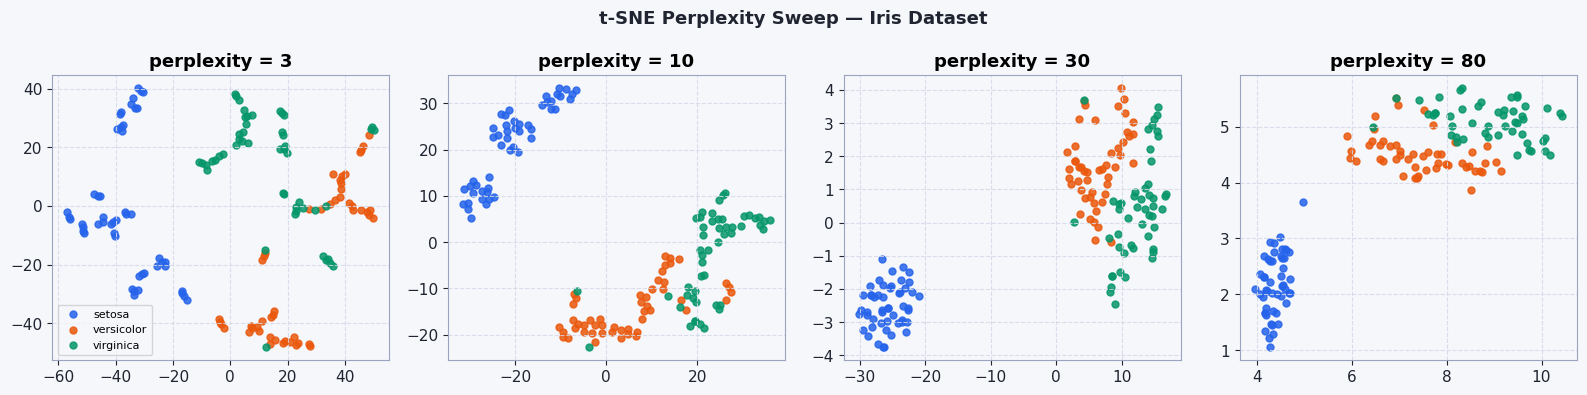

perplexity=3  → fragmented micro-clusters (unstable)
perplexity=30 → clean separation (recommended)
perplexity=80 → cluster boundaries soften as global influence grows


In [11]:
perplexities = [3, 10, 30, 80]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, perp in zip(axes, perplexities):
    X_t = TSNE(n_components=2, perplexity=perp, learning_rate='auto', random_state=42).fit_transform(X_iris)
    for k, name in enumerate(iris.target_names):
        m = y_iris == k
        ax.scatter(X_t[m, 0], X_t[m, 1], color=colors_iris[k],
                   label=name, s=25, alpha=0.85)
    beautify(ax, title=f'perplexity = {perp}')
    if perp == 3:
        ax.legend(fontsize=8)

fig.suptitle('t-SNE Perplexity Sweep \u2014 Iris Dataset',
             fontsize=13, fontweight='bold', color=PALETTE['ink'])
plt.tight_layout()
plt.show()

print('perplexity=3  \u2192 fragmented micro-clusters (unstable)')
print('perplexity=30 \u2192 clean separation (recommended)')
print('perplexity=80 \u2192 cluster boundaries soften as global influence grows')

---

## 4. UMAP — Uniform Manifold Approximation and Projection

UMAP was introduced by **McInnes, Healy & Melville (2018)**. It is grounded in **Riemannian geometry** and **algebraic topology**. At a high level, UMAP:

1. Builds a **fuzzy topological graph** in the high-dimensional space.
2. Optimizes a low-dimensional layout whose graph matches the original.

### Step 1 — Local metric and fuzzy similarities

For each point $x_i$, let $\rho_i$ = distance to its 1st nearest neighbor. Define:

$$w_{ij}^{\text{high}} = \exp\!\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)$$

where $\sigma_i$ is chosen so that $\sum_j w_{ij} = \log_2(n\_\text{neighbors})$. Symmetrize:

$$\bar{w}_{ij} = w_{ij} + w_{ji} - w_{ij} \cdot w_{ji}$$

### Step 2 — Low-dimensional similarity

$$w_{ij}^{\text{low}} = \left(1 + a \cdot \|y_i - y_j\|^{2b}\right)^{-1}$$

Parameters $a, b$ are determined by `min_dist`.

### Step 3 — Cross-entropy optimization

$$\mathcal{L} = \sum_{i \neq j}\left[w_{ij}^{\text{high}} \log \frac{w_{ij}^{\text{high}}}{w_{ij}^{\text{low}}} + (1 - w_{ij}^{\text{high}}) \log \frac{1-w_{ij}^{\text{high}}}{1-w_{ij}^{\text{low}}}\right]$$

Optimized with **SGD + negative sampling** → much faster than t-SNE for large datasets.

### Key Hyperparameters

| Parameter | Typical range | Effect |
|---|---|---|
| `n_neighbors` | 5 – 100 | Local vs global structure balance |
| `min_dist` | 0.0 – 1.0 | Cluster compactness in the embedding |
| `metric` | `'euclidean'`, `'cosine'`, … | Distance used to build the graph |
| `n_components` | 2, 3 | Output dimensionality |

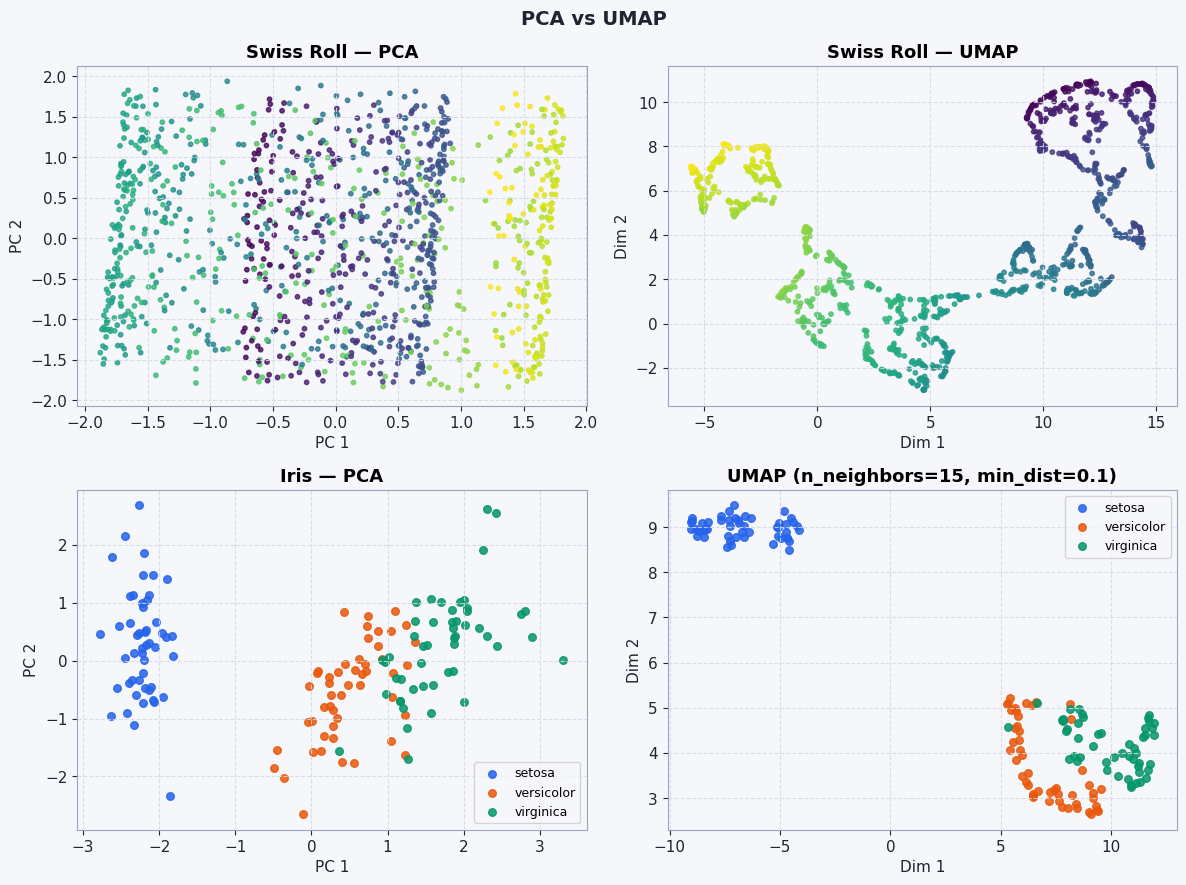

UMAP unrolls the Swiss Roll smoothly and fully separates all Iris species.


In [7]:
X_roll_umap = umap.UMAP(n_neighbors=15, min_dist=0.1,
                        random_state=42).fit_transform(X_roll_sc)
X_iris_umap = umap.UMAP(n_neighbors=15, min_dist=0.1,
                        random_state=42).fit_transform(X_iris)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(X_roll_pca[:, 0], X_roll_pca[:, 1],
                   c=c_roll, cmap='viridis', s=10, alpha=0.8)
beautify(axes[0, 0], title='Swiss Roll — PCA', xlabel='PC 1', ylabel='PC 2')

axes[0, 1].scatter(X_roll_umap[:, 0], X_roll_umap[:, 1],
                   c=c_roll, cmap='viridis', s=10, alpha=0.8)
beautify(axes[0, 1], title='Swiss Roll — UMAP', xlabel='Dim 1', ylabel='Dim 2')

for k, name in enumerate(iris.target_names):
    m = y_iris == k
    axes[1, 0].scatter(X_iris_pca[m, 0], X_iris_pca[m, 1],
                       color=colors_iris[k], label=name, s=30, alpha=0.85)
beautify(axes[1, 0], title='Iris — PCA', xlabel='PC 1', ylabel='PC 2')
axes[1, 0].legend(fontsize=9)

for k, name in enumerate(iris.target_names):
    m = y_iris == k
    axes[1, 1].scatter(X_iris_umap[m, 0], X_iris_umap[m, 1],
                       color=colors_iris[k], label=name, s=30, alpha=0.85)
beautify(axes[1, 1], title='UMAP (n_neighbors=15, min_dist=0.1)',
         xlabel='Dim 1', ylabel='Dim 2')
axes[1, 1].legend(fontsize=9)

fig.suptitle('PCA vs UMAP', fontsize=14, fontweight='bold', color=PALETTE['ink'])
plt.tight_layout()
plt.show()

print('UMAP unrolls the Swiss Roll smoothly and fully separates all Iris species.')

---

## 5. Tuning UMAP Hyperparameters

### `n_neighbors` — local vs global balance

Analogous to `perplexity` in t-SNE:

- **Small (e.g., 5)**: Very local view — fine detail, may fragment global structure
- **Medium (e.g., 15–30)**: Balanced; recommended for most tasks
- **Large (e.g., 100)**: Global structure preserved; local clusters may blend

### `min_dist` — compactness of clusters

Controls how tightly UMAP packs points in the embedding:

- **min_dist = 0.0**: Tight, compact clusters — best for discrete group identification
- **min_dist = 0.5**: Loose, continuous spread — better for manifold topology
- **min_dist → 1.0**: Very diffuse layout

> **Tip**: Use `min_dist=0.0` for clustering analysis; `min_dist=0.5` for topological exploration.

Let’s observe how both parameters interact on the Iris dataset:

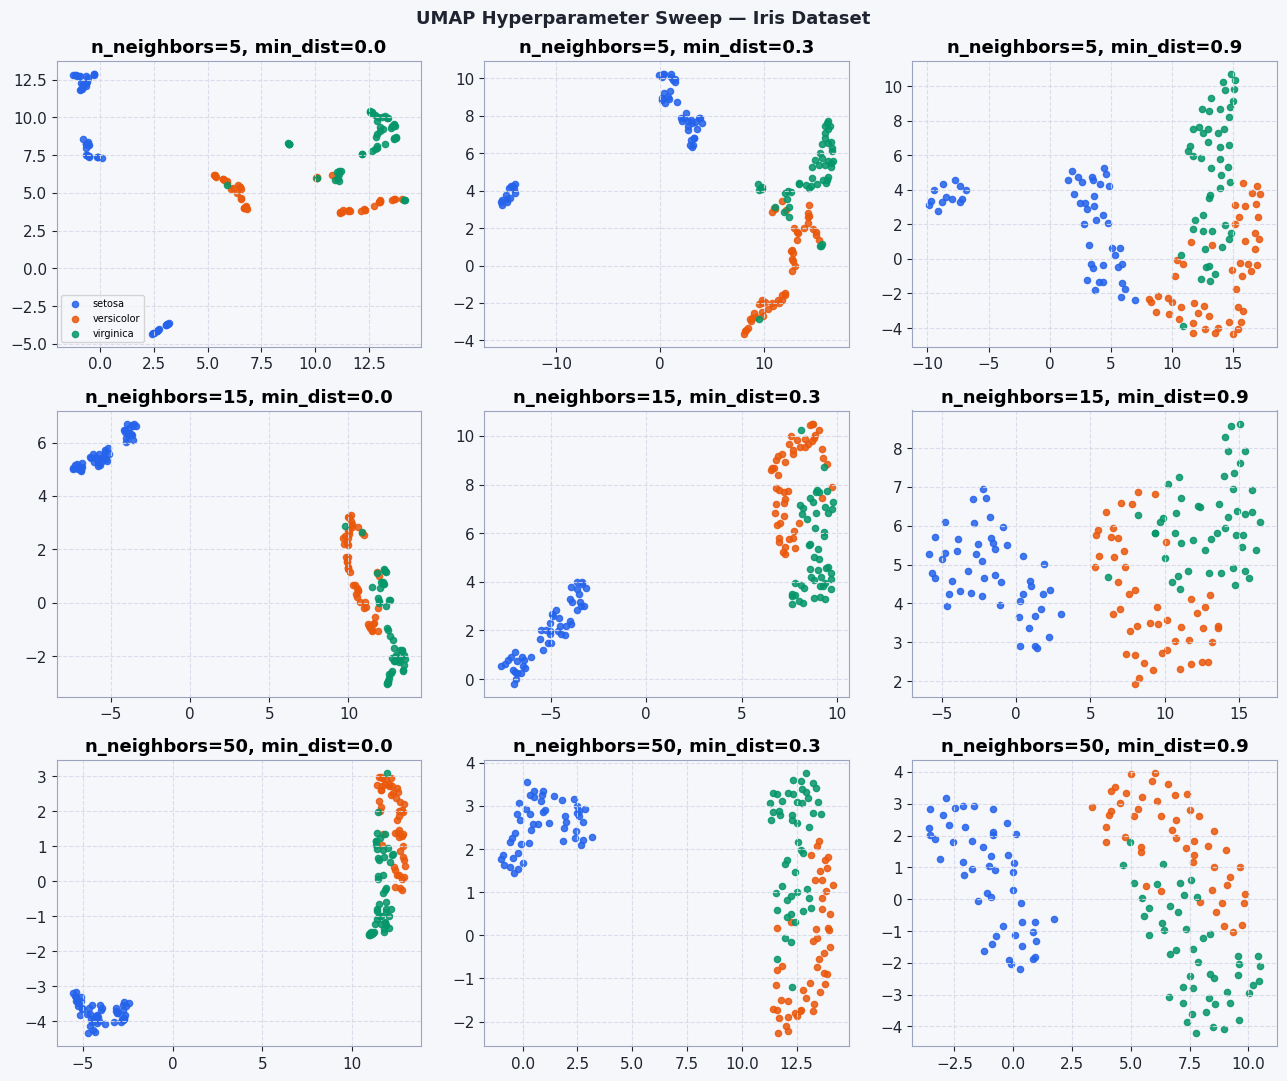

Small n_neighbors + min_dist=0.0 → tightest, most fragmented clusters
Large n_neighbors + min_dist=0.9 → diffuse, global structure visible


In [8]:
n_neighbors_vals = [5, 15, 50]
min_dist_vals    = [0.0, 0.3, 0.9]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for r, nn in enumerate(n_neighbors_vals):
    for c, md_val in enumerate(min_dist_vals):
        X_u = umap.UMAP(n_neighbors=nn, min_dist=md_val,
                        random_state=42).fit_transform(X_iris)
        ax = axes[r, c]
        for k, name in enumerate(iris.target_names):
            m = y_iris == k
            ax.scatter(X_u[m, 0], X_u[m, 1], color=colors_iris[k],
                       label=name, s=20, alpha=0.85)
        beautify(ax, title=f'n_neighbors={nn}, min_dist={md_val}')
        if r == 0 and c == 0:
            ax.legend(fontsize=7)

fig.suptitle('UMAP Hyperparameter Sweep — Iris Dataset',
             fontsize=13, fontweight='bold', color=PALETTE['ink'])
plt.tight_layout()
plt.show()

print('Small n_neighbors + min_dist=0.0 → tightest, most fragmented clusters')
print('Large n_neighbors + min_dist=0.9 → diffuse, global structure visible')

---

## 6. Head-to-Head Comparison: PCA vs t-SNE vs UMAP

We now run a comprehensive comparison on three datasets that represent common real-world scenarios where nonlinear methods win:

| Dataset | Why PCA struggles |
|---|---|
| **Digits (8×8 images)** | 64-D nonlinear manifold of digit shapes |
| **Swiss Roll** | 2-D manifold folded in 3-D |
| **Moons** | Two interlocked crescents |

We also report **1-NN cross-validated accuracy** on the 2-D embedding as a proxy for how well each method separates the classes:

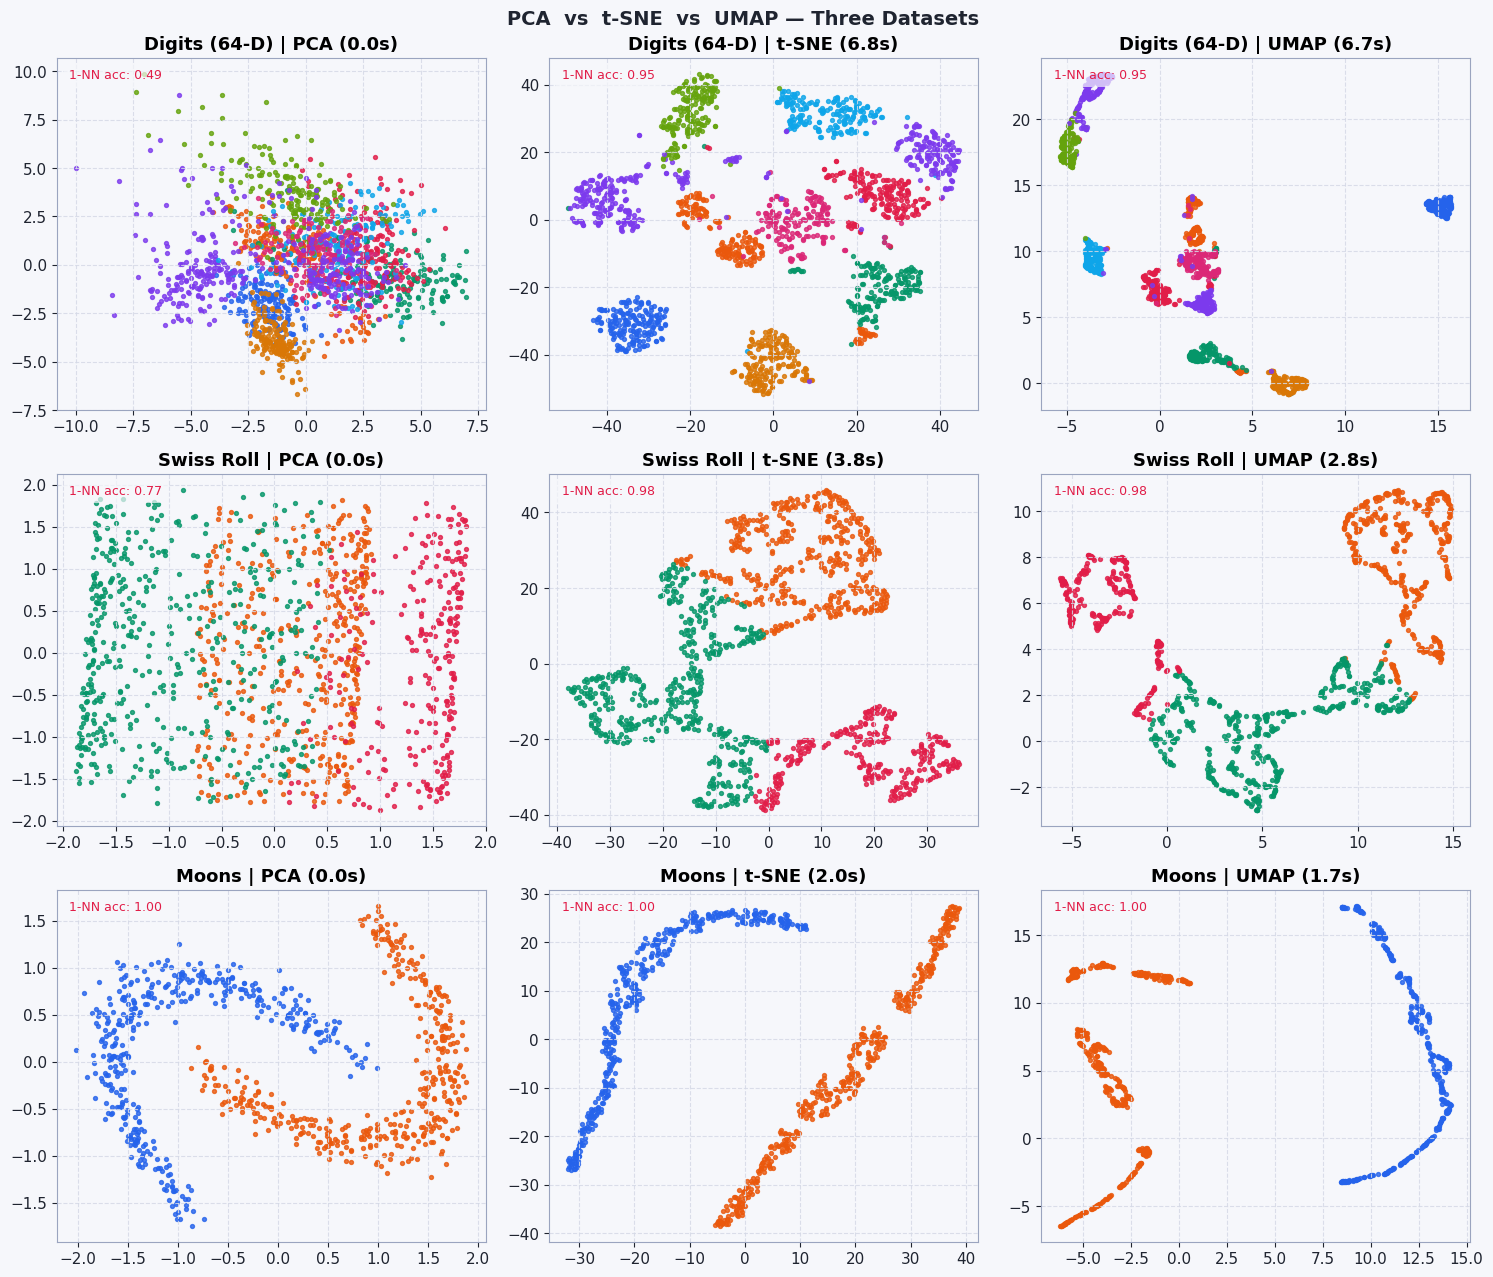

Key takeaways:
  Digits  → t-SNE and UMAP reveal tight digit clusters; PCA blends them.
  Swiss Roll → UMAP unrolls cleanly; t-SNE preserves local patches.
  Moons   → Both t-SNE and UMAP separate the crescents; PCA cannot.


In [9]:
# Datasets for the comparison grid
digits = load_digits()
X_dig  = StandardScaler().fit_transform(digits.data)
y_dig  = digits.target

X_mn, y_mn = make_moons(n_samples=800, noise=0.08, random_state=42)
X_mn = StandardScaler().fit_transform(X_mn)

col_cycle = [PALETTE['blue'], PALETTE['orange'], PALETTE['green'],
             PALETTE['rose'], PALETTE['purple'], '#0ea5e9',
             '#d97706', '#65a30d', '#db2777', '#7c3aed']

def reduce_and_plot(X, y, title, axes_row):
    methods = {
        'PCA':   lambda: PCA(n_components=2).fit_transform(X),
        't-SNE': lambda: TSNE(n_components=2, perplexity=30,
                              learning_rate='auto', random_state=42).fit_transform(X),
        'UMAP':  lambda: umap.UMAP(n_neighbors=15, min_dist=0.1,
                                    random_state=42).fit_transform(X),
    }
    for col, (name, fn) in enumerate(methods.items()):
        t0  = time.time()
        emb = fn()
        dt  = time.time() - t0
        ax  = axes_row[col]
        for i, lab in enumerate(np.unique(y)):
            m = y == lab
            ax.scatter(emb[m, 0], emb[m, 1],
                       color=col_cycle[int(lab) % len(col_cycle)],
                       s=8 if len(X) > 500 else 25, alpha=0.8)
        acc = cross_val_score(KNeighborsClassifier(n_neighbors=1),
                              emb, y, cv=3, scoring='accuracy').mean()
        ax.text(0.03, 0.97, f'1-NN acc: {acc:.2f}',
                transform=ax.transAxes, va='top', fontsize=9,
                color=PALETTE['rose'],
                bbox=dict(fc=PALETTE['bg'], ec='none', alpha=0.7))
        beautify(ax, title=f'{title} | {name} ({dt:.1f}s)')

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
reduce_and_plot(X_dig,    y_dig,  'Digits (64-D)',  axes[0])
reduce_and_plot(X_roll_sc, c_roll.astype(int) // 4, 'Swiss Roll', axes[1])
reduce_and_plot(X_mn,    y_mn,   'Moons',          axes[2])

fig.suptitle('PCA  vs  t-SNE  vs  UMAP — Three Datasets',
             fontsize=14, fontweight='bold', color=PALETTE['ink'])
plt.tight_layout()
plt.show()

print('Key takeaways:')
print('  Digits  → t-SNE and UMAP reveal tight digit clusters; PCA blends them.')
print('  Swiss Roll → UMAP unrolls cleanly; t-SNE preserves local patches.')
print('  Moons   → Both t-SNE and UMAP separate the crescents; PCA cannot.')

---

## 7. Practical Guide: Choosing the Right Method

### Quick Decision Guide

| Question | Recommendation |
|---|---|
| Is the data essentially linear? | **PCA** (fast, interpretable, deterministic) |
| Need to embed new test points? | **UMAP** (has `.transform()`) |
| Want best cluster visualization? | **t-SNE** (perplexity 20–50) |
| Large dataset (> 50k samples)? | **UMAP** (faster optimization) |
| Need global structure preserved? | **UMAP** (better than t-SNE globally) |
| Need deterministic output? | **PCA** or **UMAP** (set `random_state`) |

### Comparison Table

| Property | PCA | t-SNE | UMAP |
|---|---|---|---|
| Linear / Nonlinear | Linear | Nonlinear | Nonlinear |
| Preserves global structure | ✓ | ✗ | Partial |
| Preserves local structure | Partial | ✓✓ | ✓✓ |
| Fast on large data (>50k) | ✓✓ | ✗ | ✓ |
| Out-of-sample embedding | ✓ | ✗ | ✓ |
| Cluster distances meaningful | ✓ | ✗ | Partial |
| Hyperparameter sensitivity | Low | Medium | Medium |

### Common Pitfalls

1. **t-SNE cluster sizes and distances are NOT meaningful** — two close clusters in t-SNE may be far apart in the original space.
2. **UMAP with very small `n_neighbors`** can fragment continuous manifolds into disconnected blobs.
3. **Do not compare t-SNE runs** with different `perplexity` or `random_state` — global layout changes completely.
4. **Always `StandardScaler`** before running t-SNE or UMAP — scale matters.
5. **t-SNE is non-parametric** — you cannot embed new test points without re-running the entire algorithm.

---

## Summary and Key Takeaways

### What We Learned

1. **PCA** is fast and interpretable but only captures linear variation; it fails on curved manifolds.

2. **t-SNE** converts distances into probabilities (Gaussian in high-D, Cauchy in low-D) and minimizes KL divergence. It excels at revealing **local cluster structure** but:
   - Cluster sizes and inter-cluster distances are NOT interpretable
   - Slow for large datasets ($O(n^2)$ or $O(n \log n)$ with BH approximation)
   - Key knob: `perplexity` (5–50)

3. **UMAP** builds a fuzzy topological graph using Riemannian geometry and minimizes cross-entropy. It is:
   - Faster than t-SNE for large datasets
   - Better at preserving **global** structure
   - Supports out-of-sample extension via `.transform()`
   - Key knobs: `n_neighbors` (local/global trade-off) and `min_dist` (compactness)

### Further Reading

- Van der Maaten & Hinton (2008). *Visualizing Data using t-SNE.* JMLR 9, 2579–2605.
- McInnes, Healy & Melville (2018). *UMAP: Uniform Manifold Approximation and Projection.* arXiv:1802.03426.
- scikit-learn manifold docs: https://scikit-learn.org/stable/modules/manifold.html
- UMAP documentation: https://umap-learn.readthedocs.io

---

## Exercises for Students

### Exercise 1: Perplexity Extremes on Digits
Run t-SNE on the Digits dataset with `perplexity=2` and `perplexity=200`. Describe what goes wrong in each case and explain *why* using the algorithm’s mathematical definition.

### Exercise 2: UMAP on a New Dataset
Load `sklearn.datasets.load_wine` (13 features, 3 classes). Apply PCA, t-SNE, and UMAP. Which method gives the best visual class separation? Quantify it with 1-NN cross-validated accuracy on the 2-D embeddings.

### Exercise 3: UMAP Out-of-Sample Embedding
UMAP supports `.fit()` and `.transform()` separately. Split the Iris dataset into 80\% train / 20\% test. Fit UMAP on the training set, then `.transform()` the test set. Plot training and test embeddings together — do test points land in the correct cluster regions?

### Exercise 4: Comparing Cluster Distances
Run t-SNE and UMAP on the Swiss Roll. Pick two points that are close in the original 3-D space but on opposite arms of the roll. Compare their distances in each 2-D embedding and in the PCA projection. What does this reveal about the interpretability of distances in each method?

---

**Good luck with your explorations!**